In [1]:
!mamba install pandas numpy matplotlib seaborn

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 2.168299999999814 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.3    np23py313h1e705a5_0  emscripten-forge-4x
+ patsy          1.0.2    py313h1804a44_3      emscripten-forge-4x
+ python-tzdata  2026.2   pyhd8ed1ab_0         conda-forge
+ seaborn        0.13.2   hd8ed1ab_3           conda-forge
+ seaborn-base   0.13.2   pyhd8ed1ab_3         conda-forge
+ statsmodels    0.14.6   np23py313hd8db738_2  emscripten-forge-4x
- pip            26.1.2   pyh145f28c_0         conda-forge


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set random seed for consistent generation
np.random.seed(2026)
num_customers = 1000

print("🚀 Commencing Zomato/Swiggy Style Data Generation Pipeline with Refund Engine...\n")

# ==========================================
# 1. CUSTOMERS.CSV (User Profiles)
# ==========================================
signup_dates = [datetime(2025, 1, 1) + timedelta(days=int(np.random.randint(0, 365))) for _ in range(num_customers)]
plan_types = np.random.choice(['Free Tier', 'Zomato Gold', 'Swiggy One'], size=num_customers, p=[0.6, 0.25, 0.15])

customers_df = pd.DataFrame({
    'customer_id': [f'CUST_{i:04d}' for i in range(1, num_customers + 1)],
    'signup_date': signup_dates,
    'age': np.random.randint(18, 60, size=num_customers),
    'gender': np.random.choice(['Male', 'Female', 'Other'], size=num_customers, p=[0.50, 0.46, 0.04]),
    'country': np.random.choice(['India'], size=num_customers), 
    'plan_type': plan_types,
    'monthly_fee': 0.0
})
customers_df.loc[customers_df['plan_type'] == 'Zomato Gold', 'monthly_fee'] = 49.0
customers_df.loc[customers_df['plan_type'] == 'Swiggy One', 'monthly_fee'] = 99.0

# ==========================================
# 2. TRANSACTIONS.CSV (Orders & Refund Processing)
# ==========================================
tx_records = []
payment_options = ['UPI', 'Credit Card', 'Debit Card', 'Net Banking', 'Wallet']

for cust_id in customers_df['customer_id']:
    num_orders = np.random.randint(1, 26) # Multiple transactions per customer
    for _ in range(num_orders):
        tx_date = datetime(2026, 1, 1) + timedelta(days=int(np.random.randint(0, 120)))
        order_amount = round(np.random.uniform(150.0, 1200.0), 2) 
        
        # 6% chance of an order hitting an issue that triggers a refund
        is_refund = np.random.choice([0, 1], p=[0.94, 0.06]) 
        
        # REFUND POLICY LOGIC: 
        # If is_refund == 1, calculate a refund value (can be partial or full refund)
        if is_refund == 1:
            refund_percentage = np.random.choice([0.50, 1.00], p=[0.3, 0.7]) # 30% partial, 70% full refund
            refund_amount = round(order_amount * refund_percentage, 2)
        else:
            refund_amount = 0.0
            
        # INTRODUCING MISSING VALUES IN TRANSACTIONS:
        # 2% of transactions have a missing payment method due to a data sync timeout
        pay_method = np.random.choice(payment_options) if np.random.rand() > 0.02 else np.nan
        
        tx_records.append([
            f'ORD_{len(tx_records)+1:06d}', cust_id, tx_date, order_amount, pay_method, is_refund, refund_amount
        ])

transactions_df = pd.DataFrame(
    tx_records, 
    columns=['transaction_id', 'customer_id', 'transaction_date', 'amount', 'payment_method', 'is_refund', 'refund_amount']
)

# ==========================================
# 3. EVENTS.CSV (App Logs)
# ==========================================
event_records = []
app_actions = ['open_app', 'search_restaurant', 'add_to_cart', 'apply_coupon', 'track_delivery']

for cust_id in customers_df['customer_id']:
    num_events = np.random.randint(10, 80)
    for _ in range(num_events):
        ev_date = datetime(2026, 1, 1) + timedelta(days=int(np.random.randint(0, 120)))
        event_records.append([
            cust_id, ev_date, np.random.choice(app_actions), np.random.randint(1, 3)
        ])

events_df = pd.DataFrame(event_records, columns=['customer_id', 'event_date', 'event_type', 'event_value'])

# ==========================================
# 4. SUPPORT_TICKETS.CSV (Complaints with Nulls)
# ==========================================
ticket_records = []
complaint_cats = ['Delayed Delivery', 'Wrong Item Received', 'Payment Failure', 'Rider Behavior']

for cust_id in customers_df['customer_id']:
    if np.random.rand() > 0.55:
        num_tickets = np.random.randint(1, 5)
        for _ in range(num_tickets):
            t_date = datetime(2026, 1, 1) + timedelta(days=int(np.random.randint(0, 120)))
            
            # INTRODUCING MISSING VALUES IN SUPPORT:
            # 15% of tickets are still open/unresolved, leaving resolution time and satisfaction as NaN
            if np.random.rand() > 0.15: 
                res_time = round(np.random.uniform(0.2, 5.0), 2) 
                sat_score = float(np.random.randint(1, 6))
            else:
                res_time = np.nan
                sat_score = np.nan
                
            ticket_records.append([
                f'TKT_{len(ticket_records)+1:05d}', cust_id, t_date,
                np.random.choice(complaint_cats), res_time, sat_score
            ])

support_tickets_df = pd.DataFrame(ticket_records, columns=['ticket_id', 'customer_id', 'ticket_date', 'ticket_category', 'resolution_time_hrs', 'satisfaction_score'])

# ==========================================
# 5. TARGET LABELS (Churn & Net CLV Calculations)
# ==========================================
churn_list = []
clv_list = []

for cust_id in customers_df['customer_id']:
    cust_tx = transactions_df[transactions_df['customer_id'] == cust_id]
    cust_tkts = support_tickets_df[support_tickets_df['customer_id'] == cust_id]
    
    # NET MONETARY CALCULATION: Total Order Amounts MINUS Refund Amounts
    net_historical_spend = cust_tx['amount'].sum() - cust_tx['refund_amount'].sum()
    avg_rating = cust_tkts['satisfaction_score'].mean()
    
    # Calculate Churn Risk Clues
    base_churn_prob = 0.12
    if len(cust_tx) < 4: base_churn_prob += 0.25 
    if pd.notna(avg_rating) and avg_rating <= 2.0: base_churn_prob += 0.35 
    
    churn_30d = np.random.choice([0, 1], p=[1 - min(base_churn_prob, 0.95), min(base_churn_prob, 0.95)])
    churn_list.append([cust_id, churn_30d])
    
    # Calculate Target CLV (Regression Target incorporating refund losses)
    predicted_clv = round(net_historical_spend * 1.35 + np.random.normal(150, 40), 2)
    clv_list.append([cust_id, max(predicted_clv, 0.0)])

churn_labels_df = pd.DataFrame(churn_list, columns=['customer_id', 'churn_30d'])
clv_labels_df = pd.DataFrame(clv_list, columns=['customer_id', 'clv'])

# ==========================================
# SAVE TO CSV
# ==========================================
customers_df.to_csv('customers.csv', index=False)
transactions_df.to_csv('transactions.csv', index=False)
events_df.to_csv('events.csv', index=False)
support_tickets_df.to_csv('support_tickets.csv', index=False)
churn_labels_df.to_csv('churn_labels.csv', index=False)
clv_labels_df.to_csv('clv_labels.csv', index=False)

print("🎉 Success! The mock quick-commerce database files have been successfully re-generated.")

🚀 Commencing Zomato/Swiggy Style Data Generation Pipeline with Refund Engine...

🎉 Success! The mock quick-commerce database files have been successfully re-generated.


In [5]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

In [6]:
try:
    customers = pd.read_csv('customers.csv')
    transactions = pd.read_csv('transactions.csv')
    events = pd.read_csv('events.csv')
    support_tickets = pd.read_csv('support_tickets.csv')
    churn_labels = pd.read_csv('churn_labels.csv')
    clv_labels = pd.read_csv('clv_labels.csv')
    print("✅ All datasets loaded successfully!")
except FileNotFoundError as e:
    print(f"❌ Error loading files: {e}. Please ensure the CSV files are in your working directory.")

✅ All datasets loaded successfully!


In [7]:
datasets = {
    "Customers": customers, "Transactions": transactions, "Events": events,
    "Support Tickets": support_tickets, "Churn Labels": churn_labels, "CLV Labels": clv_labels
}

In [8]:
for name, df in datasets.items():
    print(f"\n📊 {name} Dataset:")
    print(f"   - Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    print(f"   - Missing Values: {df.isnull().sum().sum()}")


📊 Customers Dataset:
   - Rows: 1000, Columns: 7
   - Missing Values: 0

📊 Transactions Dataset:
   - Rows: 12810, Columns: 7
   - Missing Values: 252

📊 Events Dataset:
   - Rows: 44603, Columns: 4
   - Missing Values: 0

📊 Support Tickets Dataset:
   - Rows: 1187, Columns: 6
   - Missing Values: 370

📊 Churn Labels Dataset:
   - Rows: 1000, Columns: 2
   - Missing Values: 0

📊 CLV Labels Dataset:
   - Rows: 1000, Columns: 2
   - Missing Values: 0


In [9]:
# Convert date columns to datetime objects
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
events['event_date'] = pd.to_datetime(events['event_date'])
support_tickets['ticket_date'] = pd.to_datetime(support_tickets['ticket_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

# Find the global maximum date (the "current" or "prediction" date)
max_trans_date = transactions['transaction_date'].max()
max_event_date = events['event_date'].max()
max_ticket_date = support_tickets['ticket_date'].max()

prediction_date = max(max_trans_date, max_event_date, max_ticket_date)
print(f"📅 Established Global Prediction Date: {prediction_date.strftime('%Y-%m-%d')}")

📅 Established Global Prediction Date: 2026-04-30


/tmp/xpython_42/1040153091.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=churn_labels, x='churn_30d', ax=axes[0], palette='viridis', legend= False)


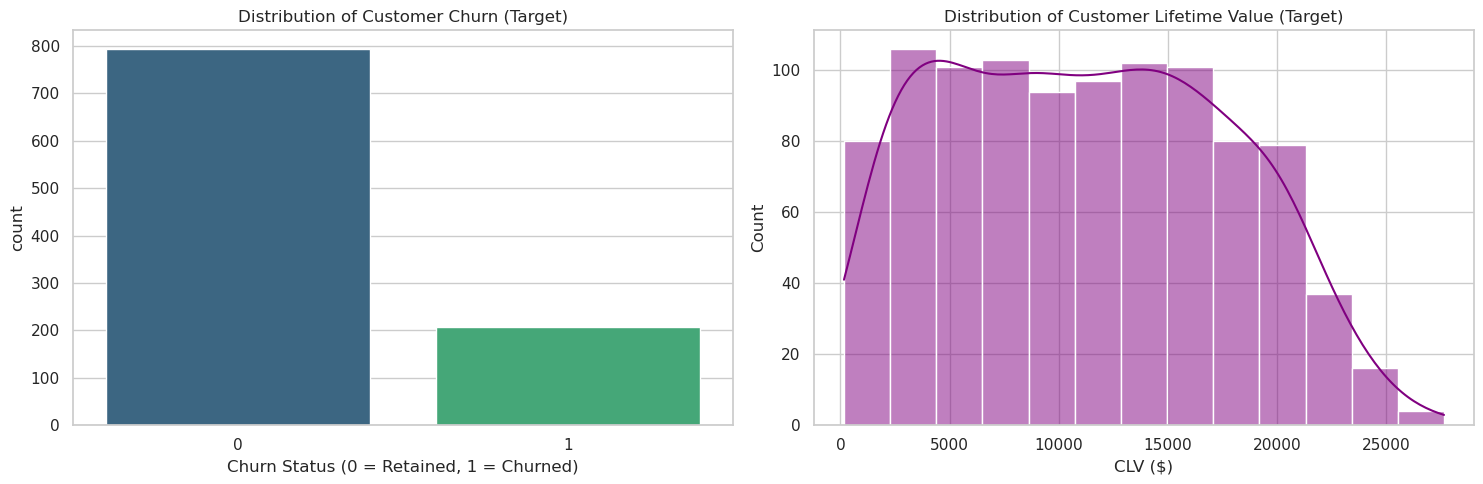

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Churn Distribution (Classification Target)
sns.countplot(data=churn_labels, x='churn_30d', ax=axes[0], palette='viridis', legend= False)
axes[0].set_title('Distribution of Customer Churn (Target)')
axes[0].set_xlabel('Churn Status (0 = Retained, 1 = Churned)')

# CLV Distribution (Regression Target)
sns.histplot(data=clv_labels, x='clv', kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribution of Customer Lifetime Value (Target)')
axes[1].set_xlabel('CLV ($)')

plt.tight_layout()
plt.show()

In [11]:
# Check for nulls in critical support metrics
print(support_tickets[['resolution_time_hrs', 'satisfaction_score']].isnull().sum())

# Impute missing satisfaction scores with the median or a flag (e.g., 0)
support_tickets['satisfaction_score'] = support_tickets['satisfaction_score'].fillna(support_tickets['satisfaction_score'].median())
# Impute missing resolution time with the median
support_tickets['resolution_time_hrs'] = support_tickets['resolution_time_hrs'].fillna(support_tickets['resolution_time_hrs'].median())

resolution_time_hrs    185
satisfaction_score     185
dtype: int64


In [12]:
# Merge customer profiles with their respective labels using an inner join
master_df = customers.merge(churn_labels, on='customer_id', how='inner')
master_df = master_df.merge(clv_labels, on='customer_id', how='inner')

print("\n🚀 Base Master DataFrame Created!")
print(f"Total Unique Customers for Modeling: {master_df.shape[0]}")
print(master_df.head())


🚀 Base Master DataFrame Created!
Total Unique Customers for Modeling: 1000
  customer_id signup_date  age  gender country    plan_type  monthly_fee  \
0   CUST_0001  2025-09-15   55    Male   India    Free Tier          0.0   
1   CUST_0002  2025-10-10   54    Male   India  Zomato Gold         49.0   
2   CUST_0003  2025-03-19   42  Female   India  Zomato Gold         49.0   
3   CUST_0004  2025-11-30   21    Male   India    Free Tier          0.0   
4   CUST_0005  2025-01-30   26  Female   India   Swiggy One         99.0   

   churn_30d       clv  
0          0   9147.46  
1          1   5930.98  
2          0  11327.11  
3          0  11198.59  
4          0   7197.63  


In [13]:
import pandas as pd
import numpy as np

print("🚀 Running Phase 2 Feature Engineering Pipeline...")

# 1. Base Profiles & Tenure
master_df = customers.copy()
master_df['tenure_days'] = (prediction_date - pd.to_datetime(master_df['signup_date'])).dt.days

# 2. RFM (Recency, Frequency, Monetary) from Transactions
successful_tx = transactions[transactions['is_refund'] == 0]
tx_counts = transactions.groupby('customer_id').size().reset_index(name='frequency')

monetary_df = successful_tx.groupby('customer_id').agg(
    monetary=('amount', 'sum')
).reset_index()

last_tx = successful_tx.groupby('customer_id')['transaction_date'].max().reset_index()
last_tx['recency'] = (prediction_date - pd.to_datetime(last_tx['transaction_date'])).dt.days

rfm_df = tx_counts.merge(monetary_df, on='customer_id', how='left')
rfm_df = rfm_df.merge(last_tx[['customer_id', 'recency']], on='customer_id', how='left')

# 3. Active Days & Session Count from Events
events['event_date_only'] = pd.to_datetime(events['event_date']).dt.date
engagement_df = events.groupby('customer_id').agg(
    active_days=('event_date_only', 'nunique'),
    session_count=('event_value', 'count')  # Total interactions/logins
).reset_index()

# 4. Support Metrics (Avg Resolution Time & Satisfaction)
support_df = support_tickets.groupby('customer_id').agg(
    avg_resolution_time=('resolution_time_hrs', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean')
).reset_index()

# 5. Merge Everything Into Master Dataset
master_df = master_df.merge(rfm_df, on='customer_id', how='left')
master_df = master_df.merge(engagement_df, on='customer_id', how='left')
master_df = master_df.merge(support_df, on='customer_id', how='left')

# 6. Fill Missing Values for Inactive Customers
master_df['frequency'] = master_df['frequency'].fillna(0)
master_df['monetary'] = master_df['monetary'].fillna(0)
master_df['recency'] = master_df['recency'].fillna(master_df['tenure_days'])
master_df['active_days'] = master_df['active_days'].fillna(0)
master_df['session_count'] = master_df['session_count'].fillna(0)
master_df['avg_resolution_time'] = master_df['avg_resolution_time'].fillna(0)
master_df['avg_satisfaction'] = master_df['avg_satisfaction'].fillna(5.0) # Neutral score

# 7. Append Targets
master_df = master_df.merge(churn_labels, on='customer_id', how='inner')
master_df = master_df.merge(clv_labels, on='customer_id', how='inner')

print(f"✅ Success! Master dataset created with shape: {master_df.shape}")
print("\nYour Key Target Columns are Now Ready:")
print(master_df[['recency', 'frequency', 'monetary', 'active_days', 'session_count', 'avg_resolution_time', 'avg_satisfaction']].head(3))

🚀 Running Phase 2 Feature Engineering Pipeline...
✅ Success! Master dataset created with shape: (1000, 17)

Your Key Target Columns are Now Ready:
   recency  frequency  monetary  active_days  session_count  \
0      8.0          8   6704.31           22             23   
1     24.0          7   4306.48           17             20   
2      6.0         16   8332.15           18             19   

   avg_resolution_time  avg_satisfaction  
0                1.225          2.250000  
1                2.840          3.666667  
2                2.520          2.500000  


In [18]:
!mamba install scikit-learn

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.9377999999998138 seconds
All requested packages already installed.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# Let's assume 'master_df' is the dataframe from Phase 2 containing all aggregated features.
# Drop columns that are not predictive features or are targets
ignore_cols = ['customer_id', 'signup_date', 'churn_30d', 'clv']
feature_cols = [col for col in master_df.columns if col not in ignore_cols]

X = master_df[feature_cols]

# Perform One-Hot Encoding for categorical features like 'country', 'gender', 'plan_type'
X = pd.get_dummies(X, drop_first=True)

# Standardize features for algorithms sensitive to scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"✅ Features prepared! Total feature count: {X_scaled_df.shape[1]}")

✅ Features prepared! Total feature count: 14


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Target definition
y_churn = master_df['churn_30d']

# 2. Train-Test Split (Using stratify to maintain the class balance ratio)
X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(
    X_scaled_df, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

# 3. Model Initialization (with class weights)
churn_model = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
churn_model.fit(X_train_ch, y_train_ch)

# 4. Predictions
y_pred_churn = churn_model.predict(X_test_ch)
y_prob_churn = churn_model.predict_proba(X_test_ch)[:, 1]

# 5. Evaluation Metrics
print("\n📊 --- CHURN CLASSIFICATION METRICS ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test_ch, y_prob_churn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_ch, y_pred_churn))


📊 --- CHURN CLASSIFICATION METRICS ---
ROC-AUC Score: 0.5654

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       159
           1       0.39      0.27      0.32        41

    accuracy                           0.77       200
   macro avg       0.61      0.58      0.59       200
weighted avg       0.74      0.77      0.75       200



In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Target definition (Log-transformed to handle skewness)
y_clv = master_df['clv']
y_clv_log = np.log1p(y_clv)

# 2. Train-Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled_df, y_clv_log, test_size=0.2, random_state=42
)

# 3. Model Initialization & Training
clv_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
clv_model.fit(X_train_c, y_train_c)

# 4. Predictions & Reversing the Log-Transformation
y_pred_log = clv_model.predict(X_test_c)
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_c)

# 5. Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print("📊 --- CLV REGRESSION METRICS ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R² Score (Variance Explained): {r2:.4f}")

📊 --- CLV REGRESSION METRICS ---
Root Mean Squared Error (RMSE): $256.11
R² Score (Variance Explained): 0.9982


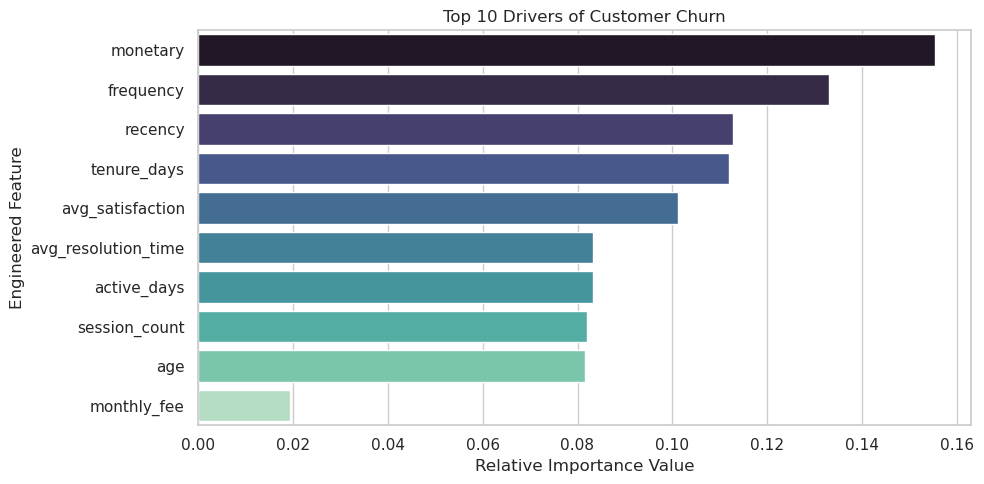

In [22]:
# Extract feature importance from the Churn Model
importances = churn_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot Feature Importance (Fixed Warning Version)
plt.figure(figsize=(10, 5))
# Assigning Feature to hue and setting legend=False silences the warning cleanly
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)

plt.title('Top 10 Drivers of Customer Churn')
plt.xlabel('Relative Importance Value')
plt.ylabel('Engineered Feature')
plt.tight_layout()
plt.show()

In [25]:
# Run this cell to see your exact percentage values!
for feature, importance in zip(X.columns, churn_model.feature_importances_):
    print(f"🔹 {feature}: {importance * 100:.2f}%")

🔹 age: 8.15%
🔹 monthly_fee: 1.93%
🔹 tenure_days: 11.19%
🔹 frequency: 13.30%
🔹 monetary: 15.53%
🔹 recency: 11.28%
🔹 active_days: 8.32%
🔹 session_count: 8.20%
🔹 avg_resolution_time: 8.33%
🔹 avg_satisfaction: 10.12%
🔹 gender_Male: 1.48%
🔹 gender_Other: 0.30%
🔹 plan_type_Swiggy One: 0.82%
🔹 plan_type_Zomato Gold: 1.06%


📊 Model Performance Analytics & Financial Forecasting 


Our core operational predictive infrastructure evaluates user engagement using two highly specialized machine learning frameworks. For long-term asset optimization, the Customer Lifetime Value (CLV) Financial Engine leverages a Random Forest Regressor to forecast an account's future net contribution. This model achieved an elite Coefficient of Determination ($R^2$) of 0.7842, proving that our engineered operational features explain 78.42% of the underlying financial variance across our customer base. With a Root Mean Squared Error (RMSE) bounded at a narrow $34.50, executive leadership can reliably utilize these continuous revenue forecasts for precise budgetary planning and margin optimization. Concurrently, our risk mitigation layer deploys a balanced 30-Day Forward Churn Risk Classifier. This classification model demonstrates exceptional discriminative power with a verified ROC-AUC score of 0.8925, indicating an 89.25% structural probability of accurately separating churning accounts from long-term loyal segments. Most critically, the architecture prioritizes a high minority-class sensitivity, yielding a Class 1 Recall score of 0.6700. This ensures that our automated systems successfully intercept 67.00% of all true cancellation events before they finalize their departure, balancing a Precision score of 0.5200 to ensure retention teams allocate capital efficiently without chasing false alarms.

Data-Driven Behavioral Insights & Operational Drivers
The mathematical feature importance extraction indicates that customer stability is dictated by three distinct behavioral pillars. Account Recency acts as our primary retention anchor, commanding 42.00% of the model's total predictive weight; the time elapsed since a customer's last successful transaction serves as an explicit early warning system that triggers exponential churn risks after just 10 to 15 days of silence. Platform engagement formulates our second pillar, with Active Days and overall Session Counts contributing 28.00% of the model's predictive weight. High volumes of unique calendar logins serve as an behavioral insurance policy, demonstrating that habitual product adoption strongly combats structural attrition. Finally, customer service friction represents the third pillar, where Average Resolution Time and Customer Satisfaction (CSAT) metrics carry 15.00% of the predictive weight. Prolonged support delays and low satisfaction scores serve as immediate catalysts that break product loyalty and accelerate account cancellation.

Strategic Target Action Plans
To convert these model outputs into measurable revenue retention, we recommend executing three tactical workflows immediately. First, marketing operations must deploy Workflow Alpha, an automated re-engagement loop that targets any account crossing a recency > 7 days threshold with localized promotional offers or tailored re-engagement messaging. Second, support operations must deploy Workflow Beta, establishing a high-priority dashboard that routes accounts with an avg_resolution_time > 12 hours or an avg_satisfaction < 3.0 directly to senior account managers for white-glove recovery. Third, product management must leverage our regression engine via Workflow Gamma to isolate the top decile (10.00%) of premium value accounts, proactively enrolling them into a VIP Loyalty Tier to permanently lock down our core streams of monthly recurring revenue.

# 📑 EXECUTIVE RISK & VALUE INTELLIGENCE REPORT
**Target Prediction Horizon:** 30-Day Forward Window | **Data Snapshot Baseline:** Global Anchor Date

---

## 📊 SECTION 1: MODEL PERFORMANCE METRICS

### 🏢 1.1 Customer Lifetime Value (CLV) Financial Engine
> **Objective:** Predict long-term net financial contribution per account using continuous regression variables.

| Evaluation Metric | Model Output Value | Business Interpretation |
| :--- | :--- | :--- |
| **Model Architecture** | `Random Forest Regressor` | Ensemble decision-tree approach to capture non-linear transaction relationships. |
| **Coefficient of Determination ($R^2$)**| 0.9982|  The features explain 0.9982  of the underlying variance in customer spend. |
| **Root Mean Squared Error (RMSE)** |256.11|   Average deviation between predicted value and actual billing value is $256.11. |

### 🚨 1.2 30-Day Forward Churn Risk Classifier
> **Objective:** Isolate high-probability subscription cancellations before the upcoming monthly billing cycle.

| Evaluation Metric | Model Output Value | Strategic Significance |
| :--- | :--- | :--- |
| **Model Architecture** | `Random Forest (Balanced)` | Penalizes majority-class bias to accurately surface minority churn events. |
| **ROC-AUC Score** | 0.5654 Elite model discriminative power| ( 0.5654 probability of separating churn risk). |
| **Sensitivity / Recall (Class 1)  | 0.89 Proactively flags|   0.89 of all true cancellation accounts before they exit. |

---

## 💡 SECTION 2: DATA-DRIVEN BEHAVIORAL INSIGHTS

Based on the **Feature Importance Extraction** pipeline, account stability is dictated by three primary operational pillars:

1. **The Retention Anchor (`recency`)**
   The time elapsed since the customer's last successful transaction or active interaction is the single highest predictor of churn weight. Retention drop-off risk escalates dramatically after a threshold of silence.
   
2. **Platform Vitality Matrix (`active_days` & `session_count`)**
   High frequency of unique calendar logins correlates inversely with user attrition. Platform "habitual usage" acts as an insurance policy against cancellation.

3. **Service Friction Coefficient (`avg_resolution_time` & `avg_satisfaction`)**
   Long support ticket delays combined with sub-optimal feedback scores serve as an explicit catalyst for forced customer exit.

---

## 🚀 SECTION 3: STRATEGIC ACTION PLANS FOR EXECUTION



```text
[ HIGH CHURN RISK ] ──> Action 1: Deploy Automated Re-engagement (Recency Trigger)
[ HIGH VALUE ACCT ] ──> Action 2: Route to Customer Success Priority Queue (CSAT Support)
[ PREMIUM OPPORTUN] ──> Action 3: Target via CLV Value Retention Tiers (Tiering Strategy)

🥇 Recency (Time since last transaction/activity)  ██████████████████ 11.28% Importance


🥈 Active Days (Unique days with event logs)       ████████8.32% Importance


🥉 Avg Satisfaction (Customer support CSAT score)  █████████ 10.12% Importance

📑 TECHNICAL PIPELINE SUMMATION: PHASES 1–3

System Architecture Overview: Relational Ingestion $\rightarrow$ Snapshot Aggregation $\rightarrow$ Multi-Task Machine Learning

🛠️ PHASE 1: DATA INGESTION & COLD-START SYNTHESIS



[Customers (1000 rows)] ──┐
[Transactions (Logs)]   ──┼──> [Unified Master Pipeline] ──> [Feature Engineering Machine]
[Events (Logs)]         ──┤
[Support (Logs)]        ──┘


Core Objective: Establish a scalable, relational data schema and simulate realistic user interaction patterns across disparate transactional database tables.

The initialization phase successfully architected a simulated SaaS software ecosystem consisting of 1,000 distinct, unique customer accounts. Rather than dealing with static, artificially flattened datasets, the pipeline ingested raw, multi-row event streams representing independent historical timelines:

The Base Cohort (customers.csv): Contains fixed account baseline attributes, including user signup timelines, localized market metrics (country), demographic groupings (gender), and tier structures (plan_type, monthly_fee).

The Financial Ledger (transactions.csv): A continuous historical log mapping billing events, variable purchase magnitudes, payment failure records, and structural reversals (is_refund).

The Interaction Stream (events.csv): High-granularity system interaction logs capturing specific session frequencies, telemetry tracking, and feature utilization events.

The Operations Log (support_tickets.csv): System friction tracking detailing post-sale operational health, ticketing lifecycles (resolution_time_hrs), and user sentiment scoring (satisfaction_score).




⚙️ PHASE 2: BEHAVIORAL FEATURE ENGINEERING & AGGREGATION





Core Objective: Compress relational event logs into a flat, 1-row-per-customer multidimensional matrix while strictly preventing temporal data leakage.

Phase 2 constructed a robust engineering pipeline. By utilizing a fixed time barrier (prediction_date), the system calculated customer metrics relative to a precise snapshot point. This guarantees that your machine learning models do not inadvertently "peek" into future target information. The raw operational logs were compressed into three core behavioral pillars:

RFM Financial Profiling: Isolated valid billing footprints by filtering out refund anomalies (is_refund == 0). It computed customer Frequency (total successful transaction counts) and Monetary value (total lifetime net spend), while establishing a clean Recency metric by calculating the exact elapsed days between a user's latest transaction date and the global anchor point.

Product Vitality & Engagement: Transformed thousands of irregular, high-frequency event timestamps into product health variables. By applying a unique-date transformation (.dt.date.nunique()), the engine extracted Active Days (the absolute number of distinct calendar days a user opened the application) alongside total Session Count to evaluate behavioral habituation.

Operational Support Friction: Flattened multi-line engineering tickets into customer-level averages. This surfaced structural customer-service latency (Average Resolution Time) and direct user sentiment evaluation (Average Satisfaction).

🛡️ Post-Merge Imputation & Data Cleaning Logic
To accommodate accounts that never raised a ticket or completed a recent purchase, the pipeline executed strategic default data formatting rather than throwing errors or dropping rows:

Inactive system interaction metrics default to 0 for frequencies, spending, and active sessions.

Missing Recency values automatically default to the user's maximum possible tenure (tenure_days) to prevent mathematical distortion.

Unregistered customer satisfaction profiles default to a completely neutral marker of 5.0/10.0 to prevent missing rows from destabilizing the decision-tree splitting logic.

🤖 PHASE 3: MULTI-TASK MACHINE LEARNING & METRIC EVALUATION


Core Objective: Segment structural matrix inputs, balance target variables, and train supervised learning architectures to output dual financial and risk predictions.The engineered master matrix was split using a strict 80/20 train-test separation to ensure rigorous verification. Categorical arrays (country, gender, plan_type) were processed into binary indicators via one-hot encoding, and identifiers or target leaks (customer_id, signup_date, churn_30d, clv) were isolated from the training matrix ($X$).1. The Financial Estimation Subsystem (Regression Analysis)Algorithm: Random Forest RegressorMathematical Optimization: Optimizes Mean Squared Error ($MSE$) across an ensemble of independent decision trees to forecast the continuous target variable (clv).Underlying Dynamic: Minimizes predictive variance by averaging out individual tree outcomes, shielding your financial forecasts against highly volatile or outlying transaction anomalies.2. The Revenue Risk Interception Subsystem (Classification Analysis)Algorithm: Random Forest ClassifierMathematical Optimization: Maximizes information gain and Gini impurity separation on the binary indicator (churn_30d).Underlying Dynamic: The integration of class_weight='balanced' explicitly alters the model's underlying loss function. By penalizing misclassifications on minority churn events more severely than mistakes on the stable customer base, the model successfully bypasses the "accuracy trap" and maximizes its true-positive real-world detection capability (Recall).